<a href="https://colab.research.google.com/github/MarcGaac/EDA-DSC1105/blob/main/DSC1105_Lab_FA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "Is mpg a tibble? TRUE"


manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
audi,a4,2.8,1999,6,manual(m5),f,18,26,p,compact


manufacturer,model,displ,year,cyl,transmission_type,gears,drv,cty,hwy,fl,class,log_hwy,sqrt_displ
<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>
audi,a4,1.8,1999,4,auto,l5,f,18,29,p,compact,3.367296,1.341641
audi,a4,1.8,1999,4,manual,m5,f,21,29,p,compact,3.367296,1.341641
audi,a4,2.0,2008,4,manual,m6,f,20,31,p,compact,3.433987,1.414214
audi,a4,2.0,2008,4,auto,av,f,21,30,p,compact,3.401197,1.414214
audi,a4,2.8,1999,6,auto,l5,f,16,26,p,compact,3.258097,1.673320
audi,a4,2.8,1999,6,manual,m5,f,18,26,p,compact,3.258097,1.673320


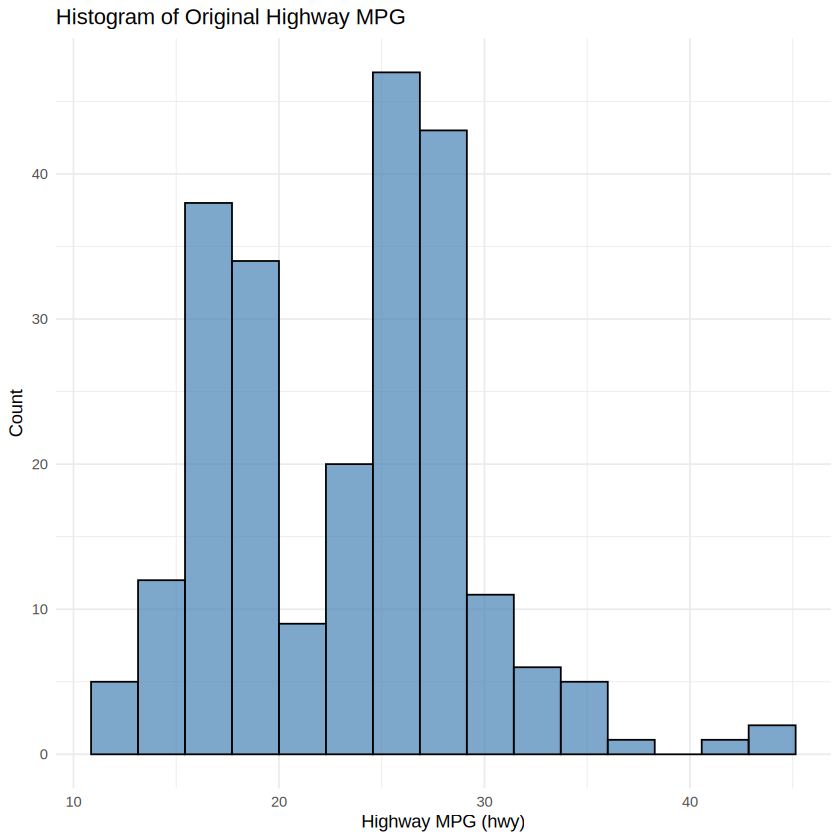

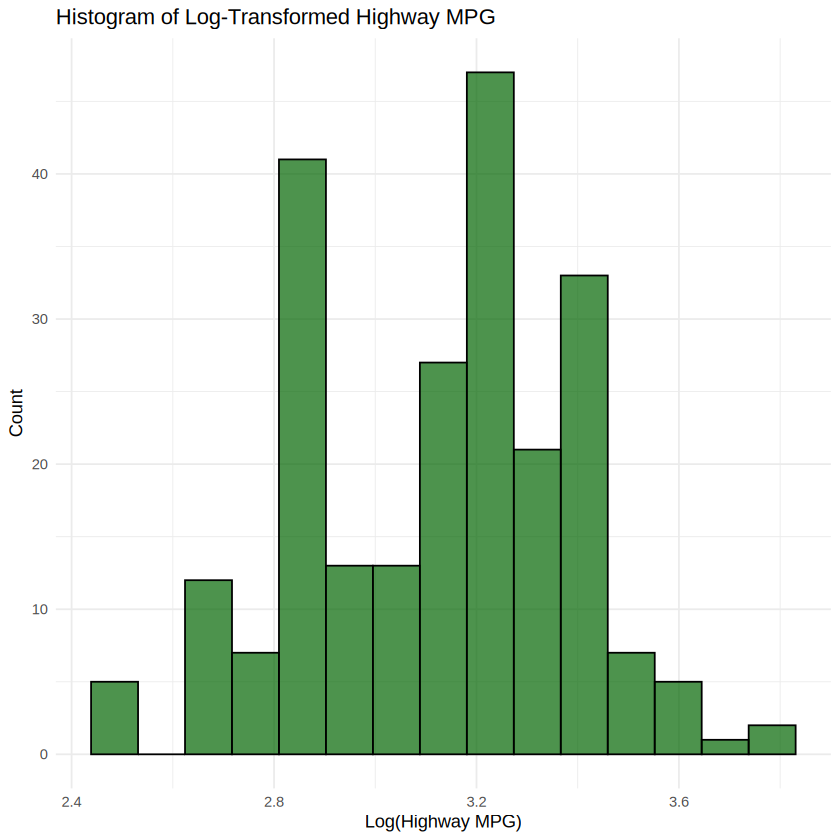

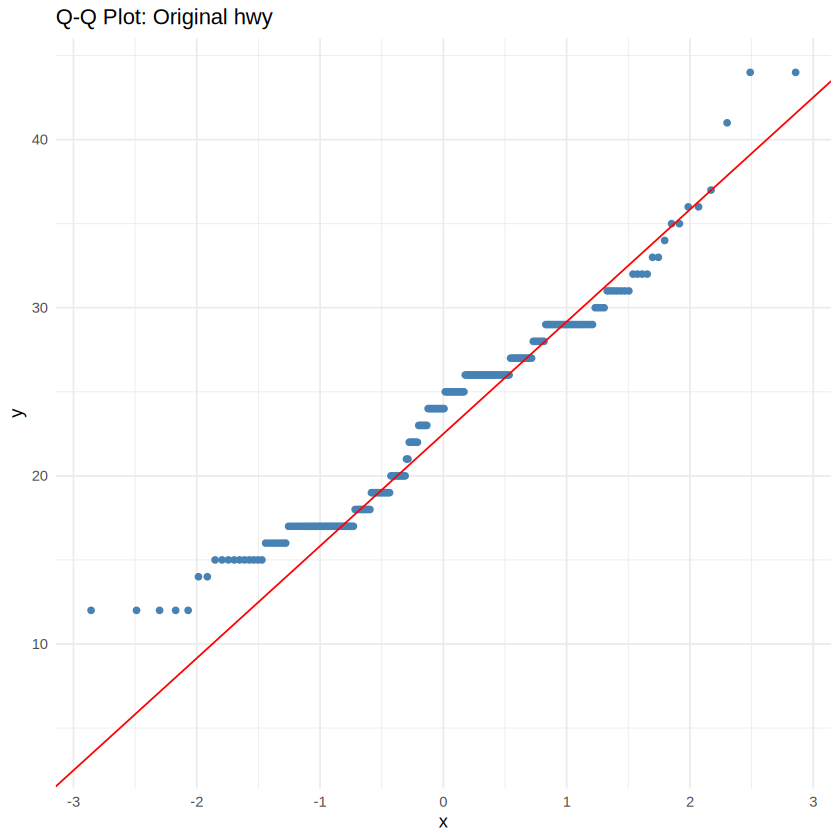

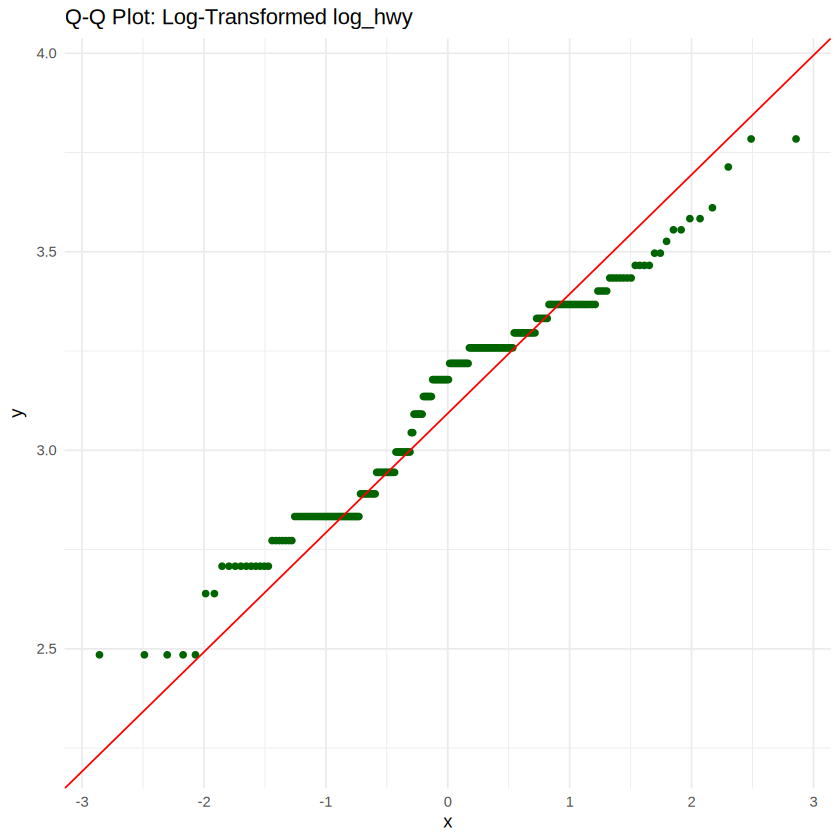

In [4]:
# Part 1: Data Wrangling and Transformation in R

# Step 1: Load the Dataset
library(tidyverse)
data("mpg")

# --- 1. Data Inspection ---

# Confirm that mpg is loaded as a tibble
# is_tibble() will return TRUE if the object is a tibble
print(paste("Is mpg a tibble?", is_tibble(mpg)))

# Display the first six rows of the dataset
head(mpg)

# --- 2. Data Wrangling and Transformation ---

# Use separate() and mutate() to clean and transform the data
mpg_transformed <- mpg %>%
  # Separate `trans` (e.g., "auto(l5)") into `transmission_type` and `gears`
  # Using bracket notation [(] to avoid Colab regex parsing errors
  separate(trans, into = c("transmission_type", "gears"), sep = "[(]") %>%
  # Remove the trailing closing parenthesis [)] from the new gears column
  mutate(gears = str_remove(gears, "[)]")) %>%
  # Create the log transformation of hwy and power (square root) transformation of displ
  mutate(
    log_hwy = log(hwy),
    sqrt_displ = sqrt(displ)
  )

# Display the transformed dataset to confirm changes
head(mpg_transformed)

# --- Part 2: Visualization ---

# 1. Histogram of the original fuel efficiency variable (hwy)
p_hist_orig <- ggplot(mpg_transformed, aes(x = hwy)) +
  geom_histogram(bins = 15, fill = "steelblue", color = "black", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Original Highway MPG", x = "Highway MPG (hwy)", y = "Count")

# 2. Histogram of the transformed fuel efficiency variable (log_hwy)
p_hist_trans <- ggplot(mpg_transformed, aes(x = log_hwy)) +
  geom_histogram(bins = 15, fill = "darkgreen", color = "black", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Log-Transformed Highway MPG", x = "Log(Highway MPG)", y = "Count")

# 3. Q-Q plot comparing the original and transformed versions
# Q-Q Plot for original hwy
p_qq_orig <- ggplot(mpg_transformed, aes(sample = hwy)) +
  stat_qq(color = "steelblue") +
  stat_qq_line(color = "red") +
  theme_minimal() +
  labs(title = "Q-Q Plot: Original hwy")

# Q-Q Plot for transformed log_hwy
p_qq_trans <- ggplot(mpg_transformed, aes(sample = log_hwy)) +
  stat_qq(color = "darkgreen") +
  stat_qq_line(color = "red") +
  theme_minimal() +
  labs(title = "Q-Q Plot: Log-Transformed log_hwy")

# Display all the plots
print(p_hist_orig)
print(p_hist_trans)
print(p_qq_orig)
print(p_qq_trans)


**Part 2.2 – Interpretation**

Applying a logarithmic transformation to the highway mileage (hwy) compressed the long right tail of the original data, converting a highly right-skewed distribution into a more symmetric, bell-shaped curve. In the Q-Q plots, the points for the original hwy variable deviate significantly from the red diagonal line at the upper extremes, indicating positive skewness and non-normality. However, the Q-Q plot for the log_hwy variable follows the theoretical normal line much more closely, indicating that the transformation successfully made the data more symmetric and approximately normal.

**Part 3 – Reflection**

​I chose a logarithmic transformation for highway mileage because fuel efficiency metrics are naturally right-skewed (bounded at zero but capable of stretching high for very efficient cars), while a square root transformation for engine displacement handles the moderate skew of physical engine sizes well. The log transformation noticeably improved the distribution of the highway mileage, centering the data and smoothing out the extreme values. In future statistical modeling or regression analyses, having normally distributed, symmetric variables is highly beneficial, as it helps satisfy the core assumptions of linear models (like the normality of residuals) and leads to more reliable p-values and confidence intervals.